<a href="https://colab.research.google.com/github/Chitlangia-Vedant/Numeric-Classification/blob/main/numeric_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, ParameterGrid, cross_val_score, RepeatedKFold, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import warnings  as ws
ws.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("../content/diabetes-dataset.csv")

In [ ]:
# print out the head of the dataframe and the shape
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [ ]:
# get the shape
df.shape

(2000, 9)

In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
0,1316
1,684


In [ ]:
# check for null entries
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# check for duplicate entries
num_duplicate_entries = df.duplicated(subset=None, keep='first').sum()
num_duplicate_entries

np.int64(1256)

In [ ]:
# to which class do the duplicates belong to
duplicate_data = df[df.duplicated(subset=None, keep='first')]
duplicate_data.Outcome.value_counts()

,count
Outcome,
0,825
1,431


<Axes: >

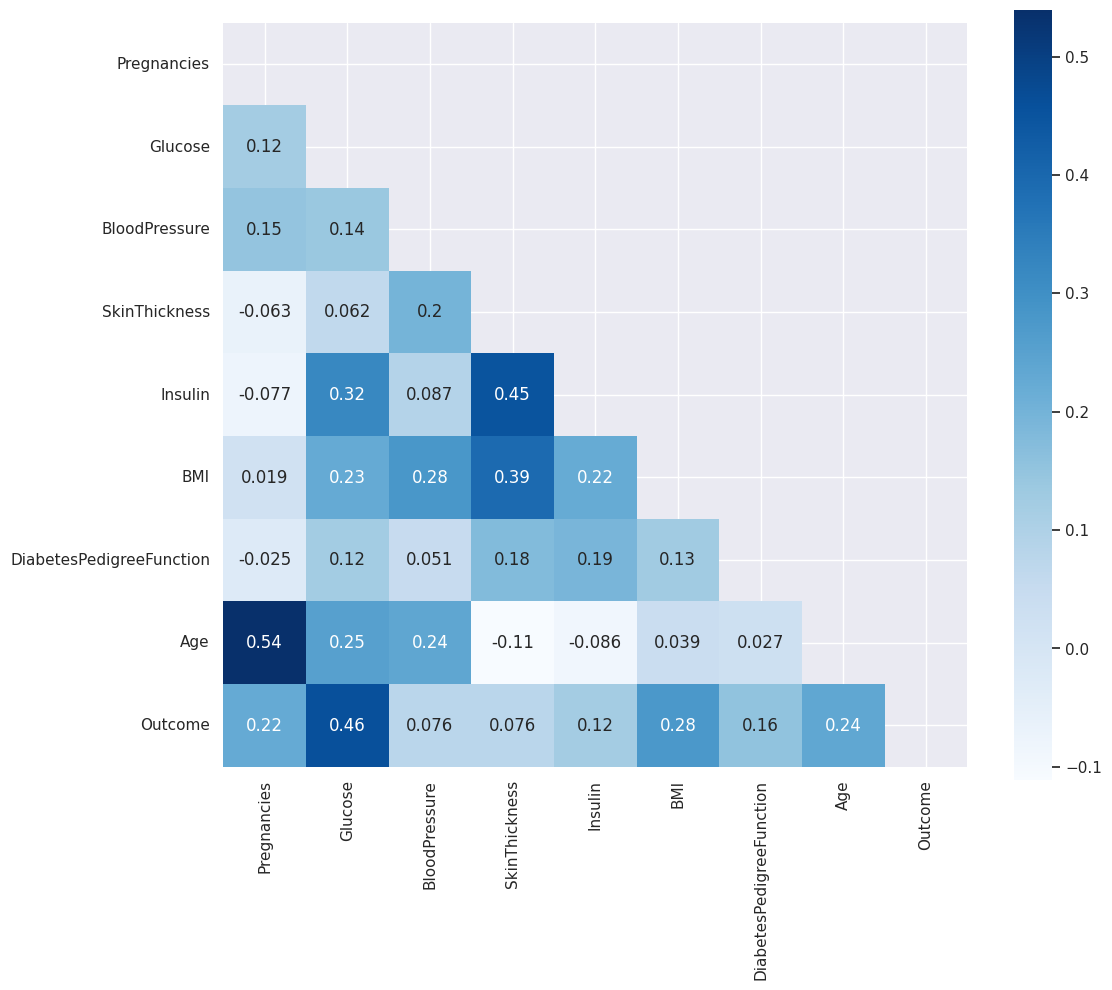

In [ ]:
corr = df.corr() # compute the correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool)) # define the upper-triangular mask for the heatmap
cmap = sns.color_palette("Blues", as_cmap=True) # define the color palette to use
plt.figure(figsize=(12, 10)) # update the figure size to dispaly nicely
sns.heatmap(corr, mask=mask, cmap=cmap, square=True, annot=True)

<Figure size 1200x1000 with 0 Axes>

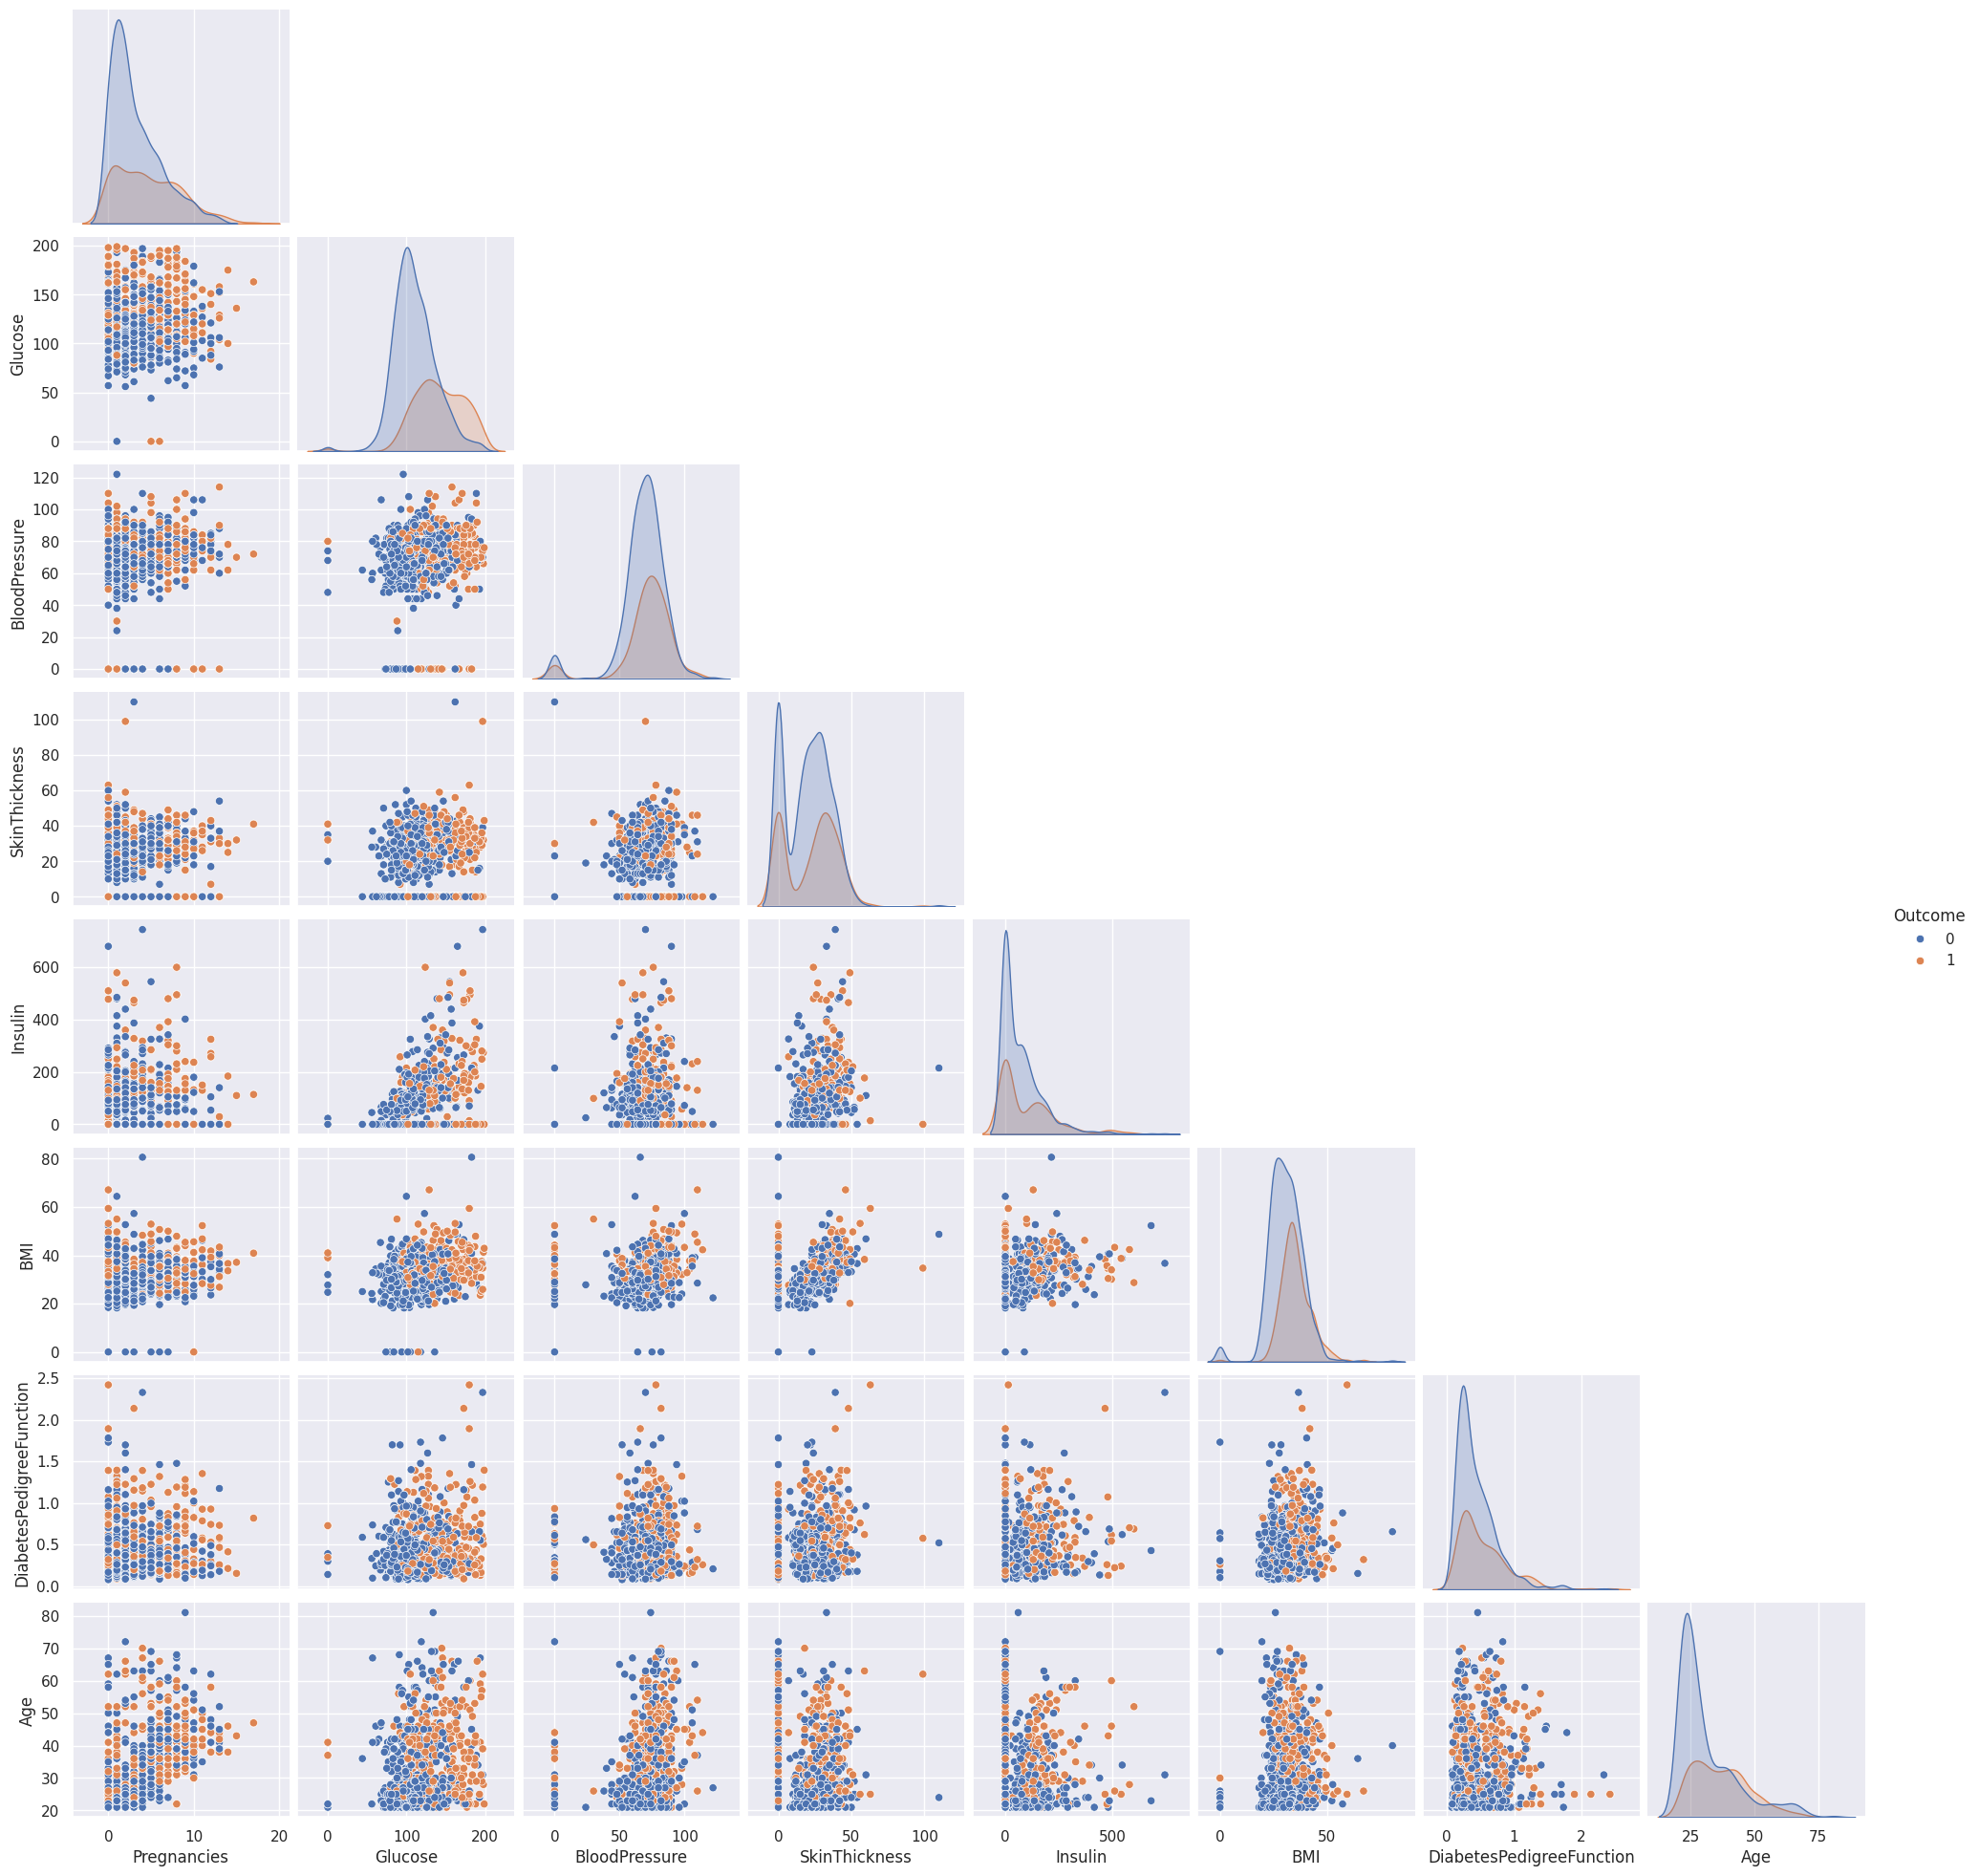

In [ ]:
# use pairplot to show relationships between features and individual distributions
plt.figure(figsize=(12, 10))
sns.pairplot(data=df, hue="Outcome", corner=True, diag_kind="kde")

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2000.0,3.70350,3.306063,0.000,1.000,3.000,6.000,17.00
Glucose,2000.0,121.18250,32.068636,0.000,99.000,117.000,141.000,199.00
BloodPressure,2000.0,69.14550,19.188315,0.000,63.500,72.000,80.000,122.00
SkinThickness,2000.0,20.93500,16.103243,0.000,0.000,23.000,32.000,110.00
Insulin,2000.0,80.25400,111.180534,0.000,0.000,40.000,130.000,744.00
BMI,2000.0,32.19300,8.149901,0.000,27.375,32.300,36.800,80.60
DiabetesPedigreeFunction,2000.0,0.47093,0.323553,0.078,0.244,0.376,0.624,2.42
Age,2000.0,33.09050,11.786423,21.000,24.000,29.000,40.000,81.00
Outcome,2000.0,0.34200,0.474498,0.000,0.000,0.000,1.000,1.00


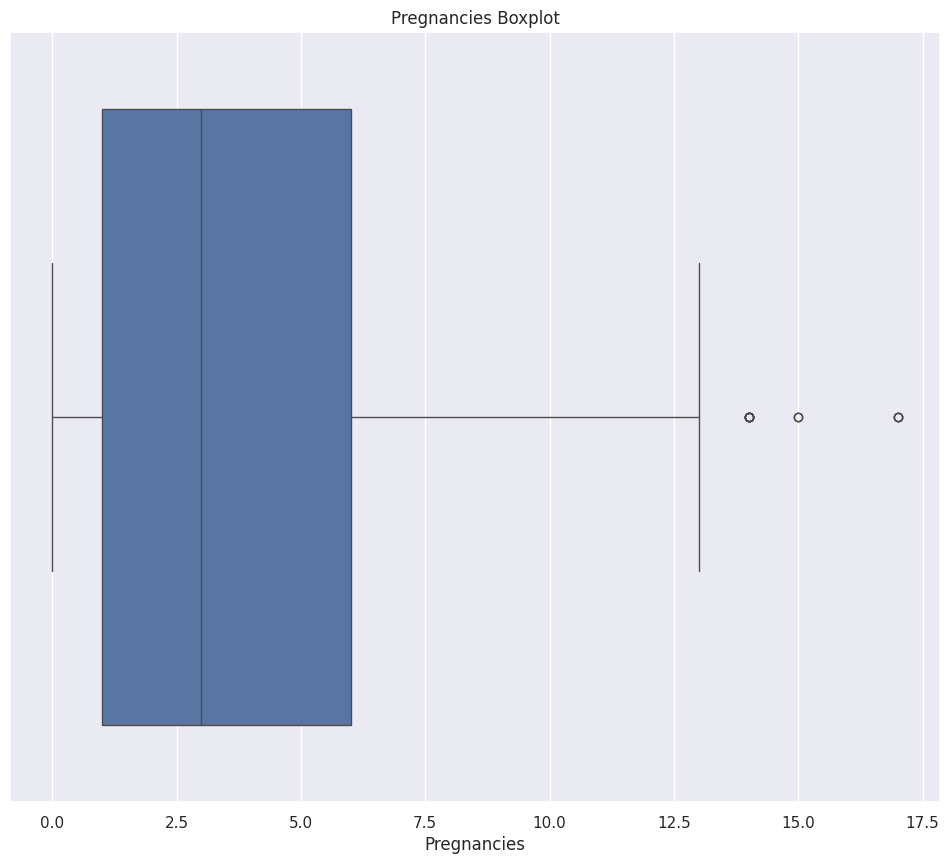

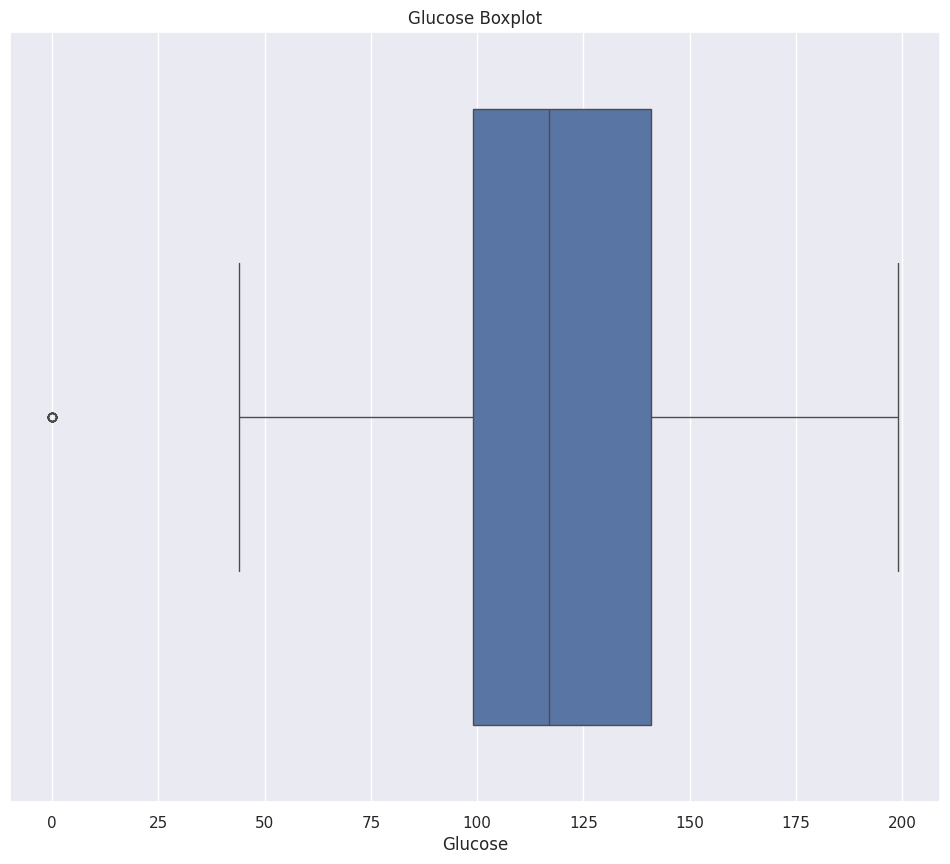

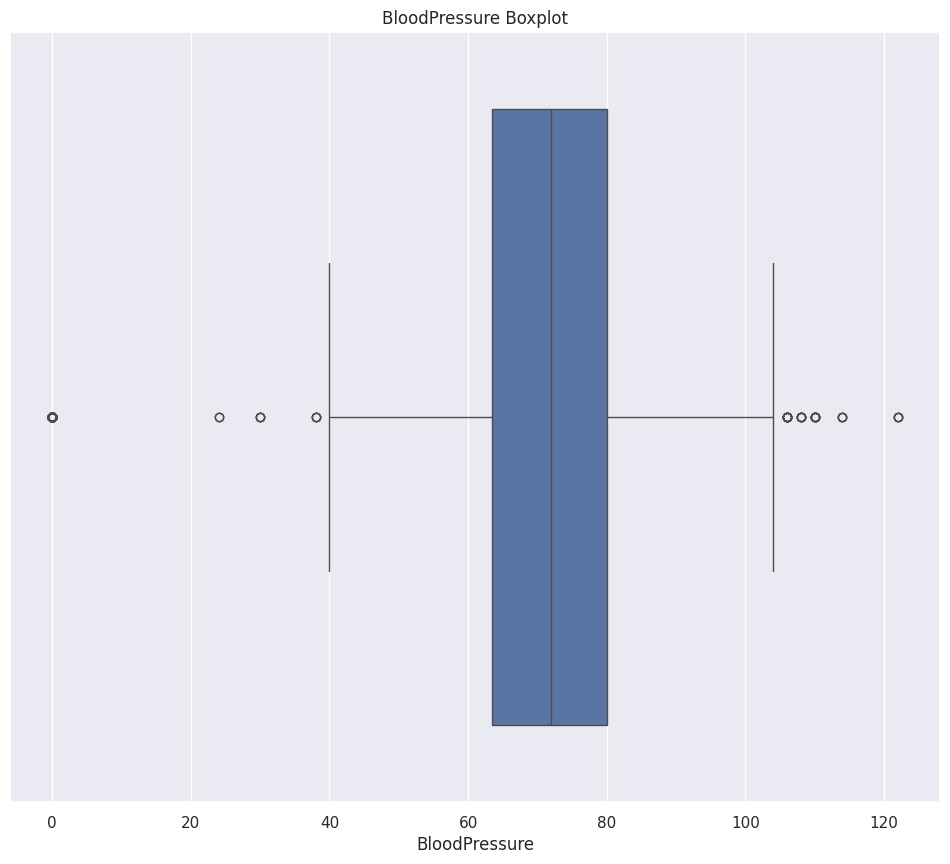

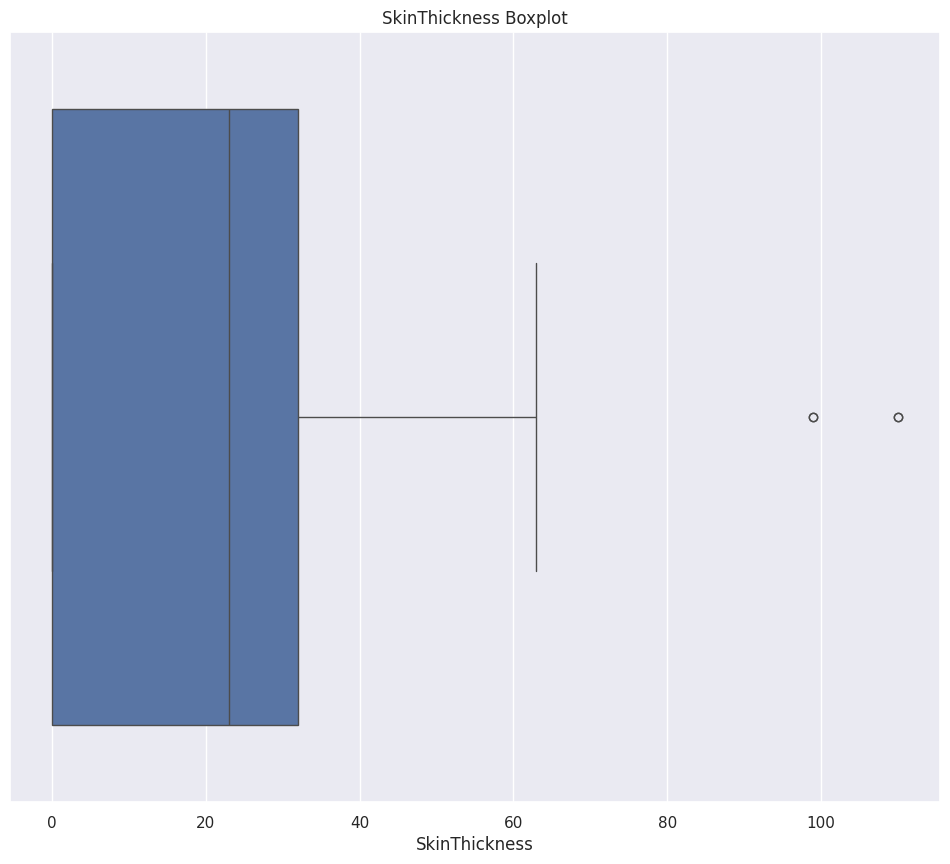

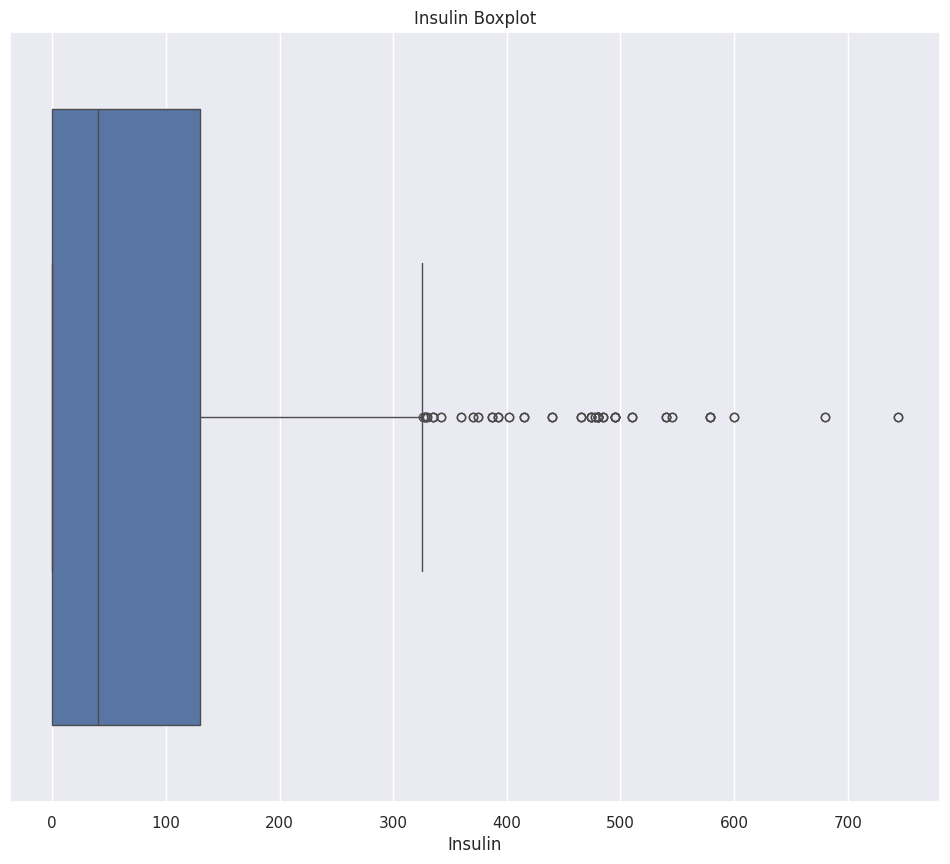

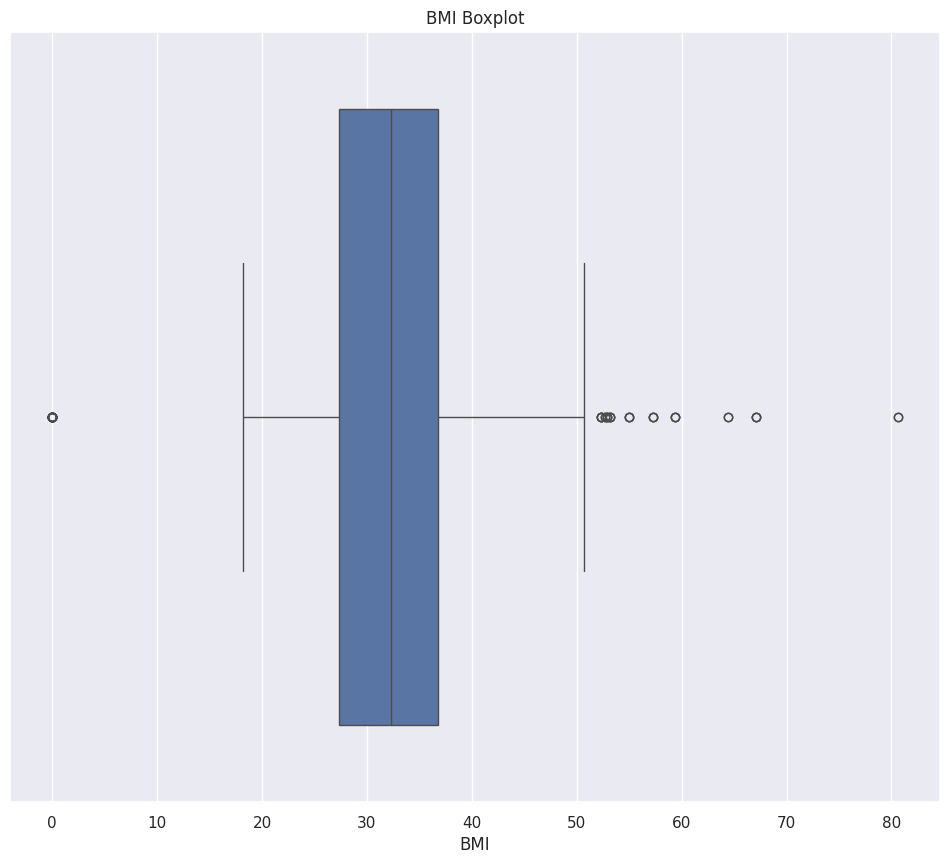

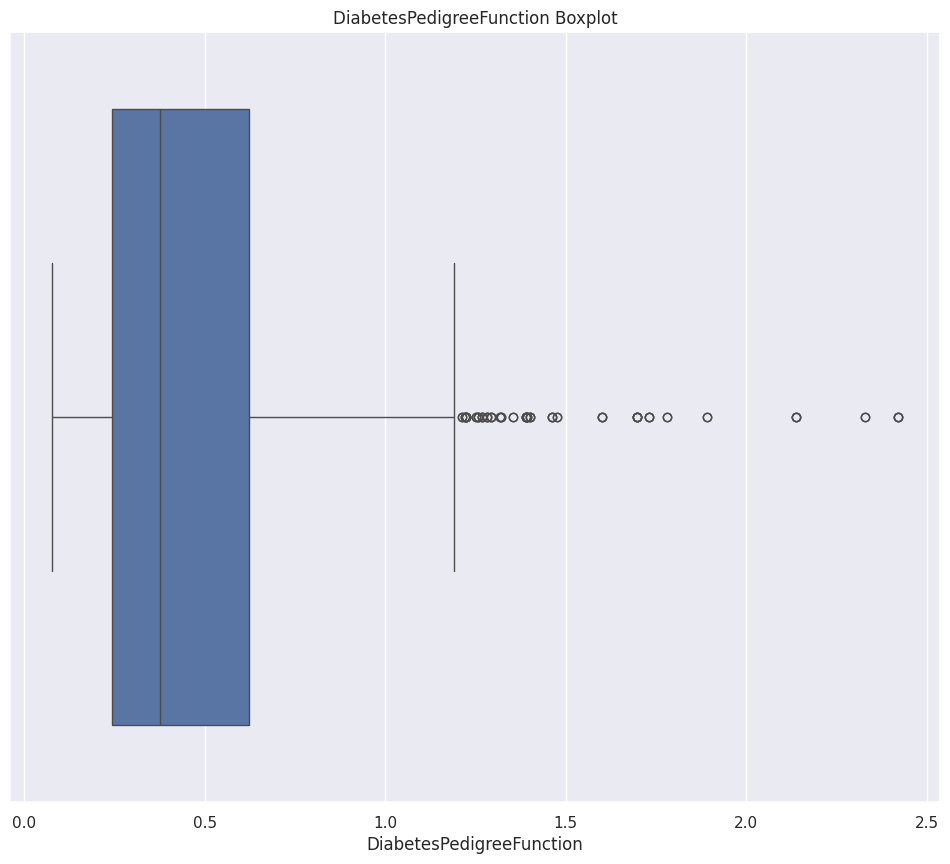

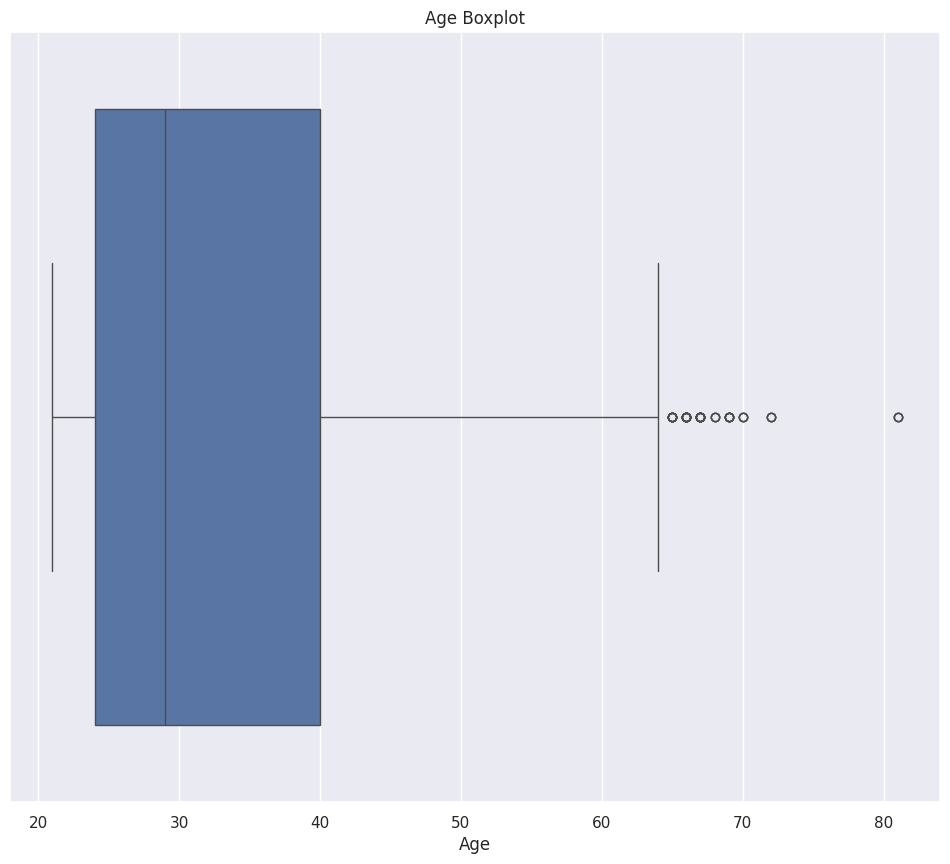

In [ ]:
for column in df.columns[:-1]:
    plt.figure(figsize=(12, 10))
    plt.title(f"{column} Boxplot")
    sns.boxplot(data=df, x=column)

In [ ]:
for column in df.columns[:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    outlier_range = (df[column] < (Q1 - 1.5*IQR)) | (df[column] > (Q3 + 1.5 * IQR))
    num_outliers = df[column][outlier_range].count()

    print(f"{column}: {num_outliers} outliers")

Pregnancies: 12 outliers
Glucose: 13 outliers
BloodPressure: 125 outliers
SkinThickness: 4 outliers
Insulin: 73 outliers
BMI: 56 outliers
DiabetesPedigreeFunction: 68 outliers
Age: 48 outliers


In [ ]:
# split our data into train/test sets to avoid data leakage
train_df, test_df = train_test_split(df, test_size=0.25, random_state=0)

In [ ]:
train_df["Outcome"].value_counts()

,count
Outcome,
0,982
1,518


In [ ]:
# get all the duplicated rows
train_dups = train_df[train_df.duplicated(subset=None, keep='first')]
# get the index of all the healthy duplicates
healthy_dups = train_dups.loc[train_df["Outcome"] == 0].index
# drop the healthy duplicates
train_df = train_df.drop(healthy_dups)

In [ ]:
train_df["Outcome"].value_counts()

,count
Outcome,
1,518
0,464


In [ ]:
# separate the data from the labels
X_train, y_train = train_df.drop(columns=["Outcome"], axis=1), train_df["Outcome"]
X_test, y_test = test_df.drop(columns=["Outcome"], axis=1), test_df["Outcome"]

# create the scaler
scaler = RobustScaler()
# fit the scaler and transform our data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
def model_Evaluate(model):

    # Predict values for Test dataset
    y_pred = model.predict(X_test)

    # Print the evaluation metrics for the dataset.
    print(classification_report(y_test, y_pred))

    # Compute and plot the Confusion matrix
    cf_matrix = confusion_matrix(y_test, y_pred)

    categories  = ['Negative','Positive']
    group_names = ['True Neg','False Pos', 'False Neg','True Pos']
    group_percentages = ['{0:.2%}'.format(value) for value in cf_matrix.flatten() / np.sum(cf_matrix)]

    labels = [f'{v1}\n{v2}' for v1, v2 in zip(group_names,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    sns.heatmap(cf_matrix, annot = labels, cmap = 'Blues',fmt = '',
                xticklabels = categories, yticklabels = categories)

    plt.xlabel("Predicted values", fontdict = {'size':14}, labelpad = 10)
    plt.ylabel("Actual values"   , fontdict = {'size':14}, labelpad = 10)
    plt.title ("Confusion Matrix", fontdict = {'size':18}, pad = 20)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       334
           1       0.99      0.99      0.99       166

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



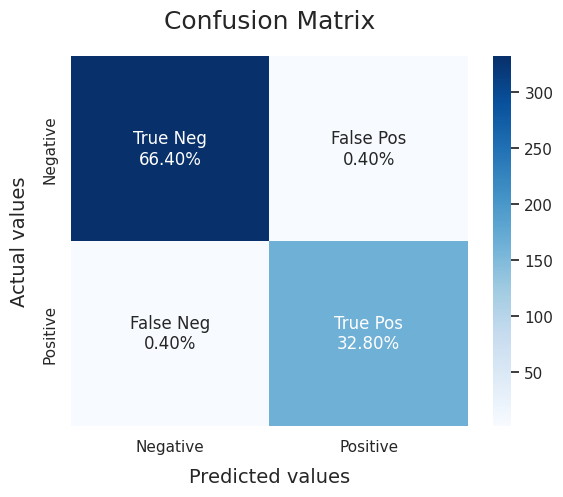

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
acc_rf= model_Evaluate(rf)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       334
           1       0.95      0.99      0.97       166

    accuracy                           0.98       500
   macro avg       0.97      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



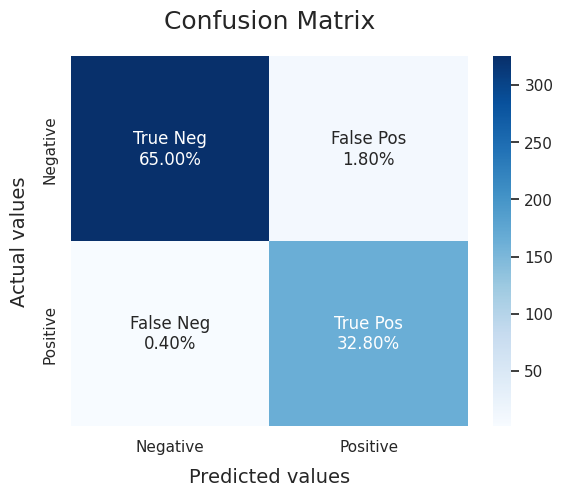

In [ ]:
dc = DecisionTreeClassifier()
dc.fit(X_train, y_train)
acc_dc= model_Evaluate(dc)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       334
           1       0.66      0.84      0.74       166

    accuracy                           0.80       500
   macro avg       0.79      0.81      0.79       500
weighted avg       0.83      0.80      0.81       500



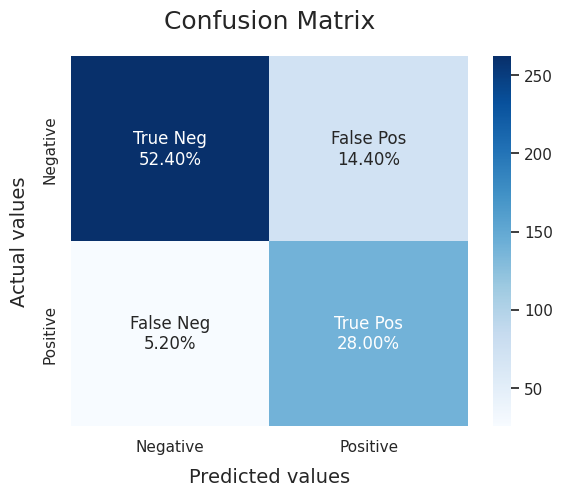

In [ ]:
kn = KNeighborsClassifier()
kn.fit(X_train, y_train)
acc_kn= model_Evaluate(kn)

              precision    recall  f1-score   support

           0       0.86      0.75      0.80       334
           1       0.60      0.75      0.67       166

    accuracy                           0.75       500
   macro avg       0.73      0.75      0.74       500
weighted avg       0.78      0.75      0.76       500



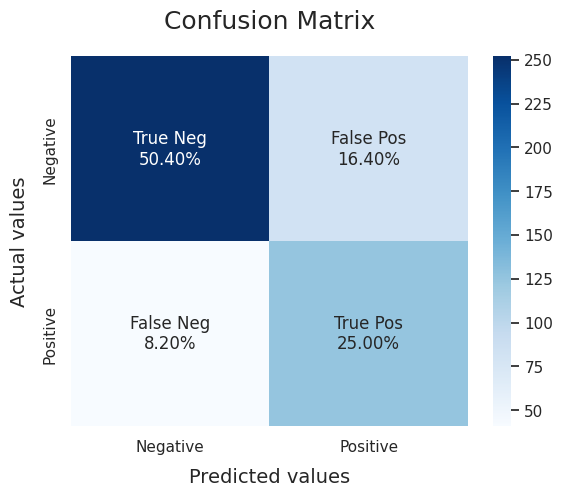

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
acc_lr= model_Evaluate(lr)

In [ ]:
model_lr = LogisticRegression().fit(X_train, y_train)
probs_lr = model_lr.predict_proba(X_test)[:, 1]

model_dt = DecisionTreeClassifier().fit(X_train, y_train)
probs_dt = model_dt.predict_proba(X_test)[:, 1]

model_kn = KNeighborsClassifier().fit(X_train, y_train)
probs_kn = model_kn.predict_proba(X_test)[:, 1]

model_rf = RandomForestClassifier().fit(X_train, y_train)
probs_rf = model_rf.predict_proba(X_test)[:, 1]

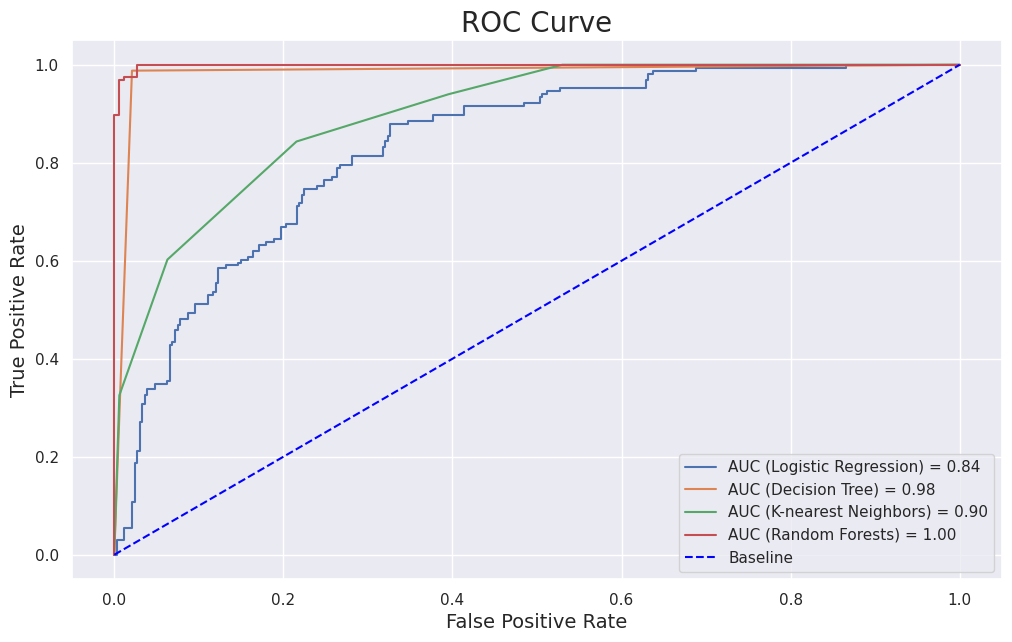

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

y_test_int = y_test.replace({'Good': 1, 'Bad': 0})
auc_lr = roc_auc_score(y_test_int, probs_lr)
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test_int, probs_lr)

auc_dt = roc_auc_score(y_test_int, probs_dt)
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_int, probs_dt)

auc_kn = roc_auc_score(y_test_int, probs_kn)
fpr_kn, tpr_kn, thresholds_kn = roc_curve(y_test_int, probs_kn)

auc_rf = roc_auc_score(y_test_int, probs_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_int, probs_rf)

plt.figure(figsize=(12, 7))
plt.plot(fpr_lr, tpr_lr, label=f'AUC (Logistic Regression) = {auc_lr:.2f}')
plt.plot(fpr_dt, tpr_dt, label=f'AUC (Decision Tree) = {auc_dt:.2f}')
plt.plot(fpr_kn, tpr_kn, label=f'AUC (K-nearest Neighbors) = {auc_kn:.2f}')
plt.plot(fpr_rf, tpr_rf, label=f'AUC (Random Forests) = {auc_rf:.2f}')
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Baseline')
plt.title('ROC Curve', size=20)
plt.xlabel('False Positive Rate', size=14)
plt.ylabel('True Positive Rate', size=14)
plt.legend();

In [ ]:
import gradio as gr

def predict_diabetes(pregnancies, glucose, bloodpressure, skinthickness, insulin, bmi, diabetespedigreefunction, age):
    # Create a numpy array from the inputs
    input_data = np.array([[pregnancies, glucose, bloodpressure, skinthickness, insulin, bmi, diabetespedigreefunction, age]])

    # Scale the input data using the fitted scaler
    scaled_data = scaler.transform(input_data)

    # Make a prediction using the trained Random Forest model
    prediction = rf.predict(scaled_data)[0]

    # Interpret the prediction
    if prediction == 1:
        return "Diabetic"
    else:
        return "Not Diabetic"

# Define Gradio input components
inputs = [
    gr.Number(label="Pregnancies"),
    gr.Number(label="Glucose"),
    gr.Number(label="Blood Pressure"),
    gr.Number(label="Skin Thickness"),
    gr.Number(label="Insulin"),
    gr.Number(label="BMI"),
    gr.Number(label="Diabetes Pedigree Function"),
    gr.Number(label="Age")
]

# Define Gradio output component
output = gr.Textbox(label="Prediction")

# Create the Gradio interface
gradio_app = gr.Interface(
    fn=predict_diabetes,
    inputs=inputs,
    outputs=output,
    title="Diabetes Prediction App",
    description="Enter patient details to predict if they have diabetes."
)

# Launch the app
gradio_app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4b882fef6628f82bb7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
